# Similar Image Sequence Compression - POC

This notebook is a proof of concept for compressing a **sequence of very similar images**
(e.g. AI-generated frames where only small regions change between one image and the next),
**without converting anything to video**.

### Idea
Instead of storing every image in full, we:
1. Store the **first frame** in full (the *reference* frame).
2. For every following frame, compute a pixel-level diff against the **previous** frame.
3. If nothing changed, store **nothing** for that frame (just a marker).
4. Group the changed pixels into separate connected regions (blobs) and discard blobs that are too
   small to be a real edit (noise/dithering), then store one tight patch **per remaining region**
   instead of a single box covering everything.
5. If there are too many separate regions, or they add up to almost the whole frame, fall back to
   storing the full frame.
6. The whole resulting payload is compressed once more with `zlib` (lossless, standard library, no installs needed).

This is the same core idea used by video codecs (I-frames / P-frames), applied directly to a folder of images.

### How to use this notebook (Google Colab)
1. Create a folder named **`input`** in the Colab file browser (left sidebar) and upload your PNG/JPG sequence into it.
   - You can drag & drop a folder, or use the Colab "Files" upload button, or mount Google Drive if you prefer.
2. Run all cells top to bottom.
3. The compressed archive will be written to `compressed_sequence.bin`.
4. The decompression section will rebuild every image into a folder named **`out`**.
5. Charts at the end compare size and time before/after compression, and visually verify the reconstruction.
6. If section 6.5 shows a small `changed px %` but a huge `bbox area %`, tune the knobs in section 1
   (see the comments there) and re-run from section 3 onward.

No `pip install` is required: `numpy`, `Pillow`, `matplotlib` and `scipy` are all preinstalled on Colab,
plus Python's standard library (`zlib`, `pickle`, `time`, `pathlib`).

In [18]:
import os
import io
import time
import pickle
import zlib
from pathlib import Path

import numpy as np
from PIL import Image
from scipy import ndimage
import matplotlib.pyplot as plt

## 1. Configuration

**After changing any value here, re-run this cell and then section 3 onward** (Cell menu ->
"Run After" in Colab works well) to actually apply the new settings - section 2 (loading) does
not need to be re-run unless you changed the images themselves.

In [19]:
INPUT_DIR = "input"
OUTPUT_ARCHIVE = "compressed_sequence.bin"
OUTPUT_DIR = "out"

# --- Color similarity ---
# Any per-pixel difference above this value (summed across RGB channels) counts as "changed".
# Use 0 for perfectly lossless PNG sequences. RAISE this (e.g. 10-30) to treat similar colors as
# the same pixel - this is the main knob for "more color similarity = more compression".
DIFF_THRESHOLD = 50 # Defaukt 0

# --- Noise filtering ---
# After thresholding, changed pixels are grouped into connected regions (blobs). Any blob smaller
# than this many pixels is treated as noise (dithering, tiny recompression artifacts) and dropped
# instead of letting it blow up a bounding box. Default 0 = keep every changed pixel (fully
# lossless). RAISE this (e.g. 10-20) if isolated noise dots are inflating your patches - note this
# makes reconstruction NEAR-lossless: dropped pixels are silently reused from the previous frame
# instead of their real (slightly different) value. Section 5 reports how big that error actually is.
MIN_BLOB_SIZE = 20

# --- Area / region limits ---
# If the changed regions add up to more than this fraction of the frame, storing patches is not
# worth it anymore -> fall back to storing the full frame instead (still lossless, just no savings).
MAX_PATCH_AREA_RATIO = 0.7

# If the change breaks into more separate regions than this, the frame is probably not a small
# localized edit anymore -> fall back to storing the full frame instead of many tiny patches.
MAX_PATCHES_PER_FRAME = 500

## 2. Load images from the `input` folder

The cell below creates the `input` folder if it does not exist yet. If it was just created (or is
empty), upload your PNG/JPG sequence into it and re-run this cell.

In [20]:
input_path = Path(INPUT_DIR)
if not input_path.exists():
    input_path.mkdir(parents=True)
    print(f"Created '{INPUT_DIR}' folder. Upload your PNG/JPG sequence into it, then re-run this cell.")

In [21]:
def load_images(folder):
    folder = Path(folder)
    if not folder.exists():
        raise FileNotFoundError(
            f"Input folder '{folder}' does not exist. Create it and upload your PNG/JPG sequence there."
        )

    valid_ext = {".png", ".jpg", ".jpeg", ".webp", ".bmp"}
    paths = sorted(p for p in folder.iterdir() if p.suffix.lower() in valid_ext)
    if not paths:
        raise FileNotFoundError(f"No images found in '{folder}'. Supported extensions: {sorted(valid_ext)}")

    images = []
    original_sizes = []
    reference_size = None

    for p in paths:
        img = Image.open(p).convert("RGB")
        if reference_size is None:
            reference_size = img.size
        elif img.size != reference_size:
            print(f"Warning: resizing '{p.name}' from {img.size} to {reference_size} to match the sequence")
            img = img.resize(reference_size)
        images.append(np.array(img))
        original_sizes.append(p.stat().st_size)

    return paths, images, original_sizes


paths, images, original_sizes = load_images(INPUT_DIR)
print(f"Loaded {len(images)} images from '{INPUT_DIR}'")
print(f"Frame size: {images[0].shape[1]}x{images[0].shape[0]}")
print(f"Total original size on disk: {sum(original_sizes) / 1024:.1f} KB")

Loaded 4 images from 'input'
Frame size: 1024x1024
Total original size on disk: 4783.0 KB


## 3. Compression

Builds one payload made of, per frame: `full` (PNG-encoded pixels), `identical` (nothing to store),
or `patch` (a *list* of bounding boxes, each with its own PNG-encoded pixels, one per separate
changed region).

Note: each stored chunk is encoded as **PNG**, not raw pixels. Raw pixel arrays are the decompressed
bitmap size (e.g. a 1024x1024 RGB frame is always 3 MB in memory, no matter how simple the image is),
which is why an earlier raw+zlib version of this notebook could end up *larger* than the original
PNG/JPEG files. PNG applies per-image prediction filters plus DEFLATE, which is far more effective on
photographic pixel data than generic zlib over a raw buffer. `zlib` is still applied once at the very
end mainly to compress the small amount of metadata (bounding boxes, frame types).

In [22]:
def find_patch_boxes(mask, min_blob_size):
    """Group changed pixels into connected regions and return one bbox per region,
    dropping regions smaller than min_blob_size (treated as noise)."""
    labeled, num_labels = ndimage.label(mask)
    boxes = []
    for label_id in range(1, num_labels + 1):
        blob_mask = labeled == label_id
        if blob_mask.sum() < min_blob_size:
            continue
        ys, xs = np.where(blob_mask)
        boxes.append((int(ys.min()), int(ys.max()) + 1, int(xs.min()), int(xs.max()) + 1))
    return boxes


def encode_png(img):
    buf = io.BytesIO()
    Image.fromarray(img).save(buf, format="PNG", optimize=True)
    return buf.getvalue()


def decode_png(data):
    return np.array(Image.open(io.BytesIO(data)).convert("RGB"))


def compress_sequence(
    images,
    diff_threshold=DIFF_THRESHOLD,
    min_blob_size=MIN_BLOB_SIZE,
    max_patch_ratio=MAX_PATCH_AREA_RATIO,
    max_patches_per_frame=MAX_PATCHES_PER_FRAME,
):
    frames_meta = []
    per_frame_stats = []
    previous = None
    frame_area = images[0].shape[0] * images[0].shape[1]

    for img in images:
        if previous is None:
            data = encode_png(img)
            frames_meta.append({"type": "full", "data": data})
            per_frame_stats.append({
                "stored_bytes": len(data), "kind": "reference",
                "bboxes": None, "area_ratio": None, "changed_pixel_ratio": None, "num_patches": None,
            })
        else:
            diff = np.abs(img.astype(np.int16) - previous.astype(np.int16)).sum(axis=-1)
            mask = diff > diff_threshold
            changed_pixel_ratio = float(mask.mean())
            boxes = find_patch_boxes(mask, min_blob_size)

            if not boxes:
                frames_meta.append({"type": "identical"})
                per_frame_stats.append({
                    "stored_bytes": 0, "kind": "identical",
                    "bboxes": None, "area_ratio": 0.0, "changed_pixel_ratio": changed_pixel_ratio, "num_patches": 0,
                })
            else:
                area_ratio = sum((y1 - y0) * (x1 - x0) for y0, y1, x0, x1 in boxes) / frame_area

                if len(boxes) > max_patches_per_frame or area_ratio > max_patch_ratio:
                    data = encode_png(img)
                    frames_meta.append({"type": "full", "data": data})
                    per_frame_stats.append({
                        "stored_bytes": len(data), "kind": "full_fallback",
                        "bboxes": boxes, "area_ratio": area_ratio,
                        "changed_pixel_ratio": changed_pixel_ratio, "num_patches": len(boxes),
                    })
                else:
                    patches = []
                    total_bytes = 0
                    for (y0, y1, x0, x1) in boxes:
                        patch_data = encode_png(img[y0:y1, x0:x1])
                        patches.append({"bbox": (y0, y1, x0, x1), "data": patch_data})
                        total_bytes += len(patch_data)
                    frames_meta.append({"type": "patch", "patches": patches})
                    per_frame_stats.append({
                        "stored_bytes": total_bytes, "kind": "patch",
                        "bboxes": boxes, "area_ratio": area_ratio,
                        "changed_pixel_ratio": changed_pixel_ratio, "num_patches": len(boxes),
                    })

        previous = img

    payload = pickle.dumps({"shape": images[0].shape, "frames": frames_meta})
    compressed = zlib.compress(payload, level=9)
    return compressed, per_frame_stats


start = time.perf_counter()
compressed_bytes, per_frame_stats = compress_sequence(
    images,
    diff_threshold=DIFF_THRESHOLD,
    min_blob_size=MIN_BLOB_SIZE,
    max_patch_ratio=MAX_PATCH_AREA_RATIO,
    max_patches_per_frame=MAX_PATCHES_PER_FRAME,
)
compress_time = time.perf_counter() - start

with open(OUTPUT_ARCHIVE, "wb") as f:
    f.write(compressed_bytes)

print(f"Compression finished in {compress_time * 1000:.1f} ms")
print(f"Archive size: {len(compressed_bytes) / 1024:.1f} KB (written to '{OUTPUT_ARCHIVE}')")

Compression finished in 9529.8 ms
Archive size: 1428.8 KB (written to 'compressed_sequence.bin')


## 4. Decompression

Rebuilds every frame in order: `full` frames are used as-is, `identical` frames copy the previous
reconstructed frame, and `patch` frames copy the previous frame and overwrite each patched region.

In [23]:
def decompress_sequence(compressed_bytes):
    payload = pickle.loads(zlib.decompress(compressed_bytes))
    frames_meta = payload["frames"]

    reconstructed = []
    previous = None

    for meta in frames_meta:
        if meta["type"] == "full":
            frame = decode_png(meta["data"])
        elif meta["type"] == "identical":
            frame = previous.copy()
        elif meta["type"] == "patch":
            frame = previous.copy()
            for p in meta["patches"]:
                y0, y1, x0, x1 = p["bbox"]
                frame[y0:y1, x0:x1] = decode_png(p["data"])
        else:
            raise ValueError(f"Unknown frame type: {meta['type']}")

        reconstructed.append(frame)
        previous = frame

    return reconstructed


with open(OUTPUT_ARCHIVE, "rb") as f:
    archive_bytes = f.read()

start = time.perf_counter()
reconstructed_images = decompress_sequence(archive_bytes)
decompress_time = time.perf_counter() - start

print(f"Decompression finished in {decompress_time * 1000:.1f} ms")

Decompression finished in 66.8 ms


## 5. Save reconstructed images to `out/` and verify accuracy

With the default settings (`DIFF_THRESHOLD = 0`, `MIN_BLOB_SIZE = 0`) this must be pixel-perfect.
If you raised either of those knobs in section 1 to get more compression, small differences here
are expected by design - this cell reports exactly how big they are so you can judge whether
they're actually imperceptible.

In [24]:
os.makedirs(OUTPUT_DIR, exist_ok=True)

max_diff_per_frame = []
for path, original, reconstructed in zip(paths, images, reconstructed_images):
    out_path = Path(OUTPUT_DIR) / path.name
    Image.fromarray(reconstructed).save(out_path)
    diff = np.abs(original.astype(np.int16) - reconstructed.astype(np.int16))
    max_diff_per_frame.append(int(diff.max()))

worst = max(max_diff_per_frame)
if worst == 0:
    print("All frames match the original pixel-for-pixel (fully lossless).")
else:
    print("Some pixels differ from the original - expected when DIFF_THRESHOLD/MIN_BLOB_SIZE are")
    print("above 0, since those knobs intentionally ignore small differences to save space:")
    for path, d in zip(paths, max_diff_per_frame):
        if d > 0:
            print(f"  {path.name}: max per-channel difference = {d} (out of 255)")

print(f"Reconstructed images saved to '{OUTPUT_DIR}'")

Some pixels differ from the original - expected when DIFF_THRESHOLD/MIN_BLOB_SIZE are
above 0, since those knobs intentionally ignore small differences to save space:
  face2.png: max per-channel difference = 67 (out of 255)
  face3.png: max per-channel difference = 94 (out of 255)
  face4.png: max per-channel difference = 129 (out of 255)
Reconstructed images saved to 'out'


## 6. Results: size, time and visual comparison

### 6.1 Total size before vs after compression

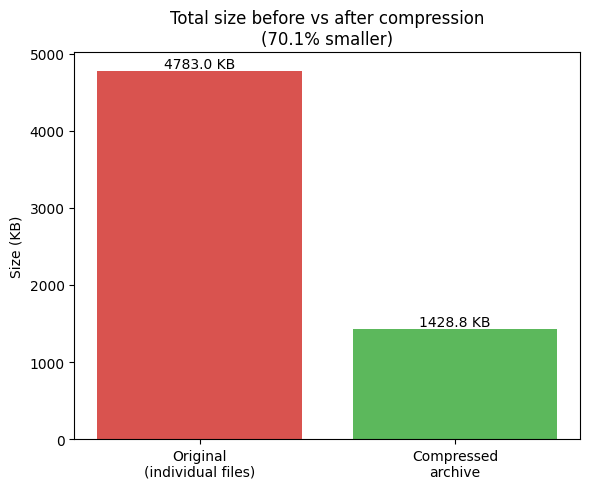

Original total size:   4783.0 KB
Compressed total size: 1428.8 KB
Space saved:           70.1%


In [25]:
total_original = sum(original_sizes)
total_compressed = len(compressed_bytes)
savings_pct = (1 - total_compressed / total_original) * 100

plt.figure(figsize=(6, 5))
bars = plt.bar(
    ["Original\n(individual files)", "Compressed\narchive"],
    [total_original / 1024, total_compressed / 1024],
    color=["#d9534f", "#5cb85c"],
)
plt.ylabel("Size (KB)")
plt.title(f"Total size before vs after compression\n({savings_pct:.1f}% smaller)")
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f"{height:.1f} KB", ha="center", va="bottom")
plt.tight_layout()
plt.show()

print(f"Original total size:   {total_original / 1024:.1f} KB")
print(f"Compressed total size: {total_compressed / 1024:.1f} KB")
print(f"Space saved:           {savings_pct:.1f}%")

### 6.2 Per-frame size: original file vs stored contribution

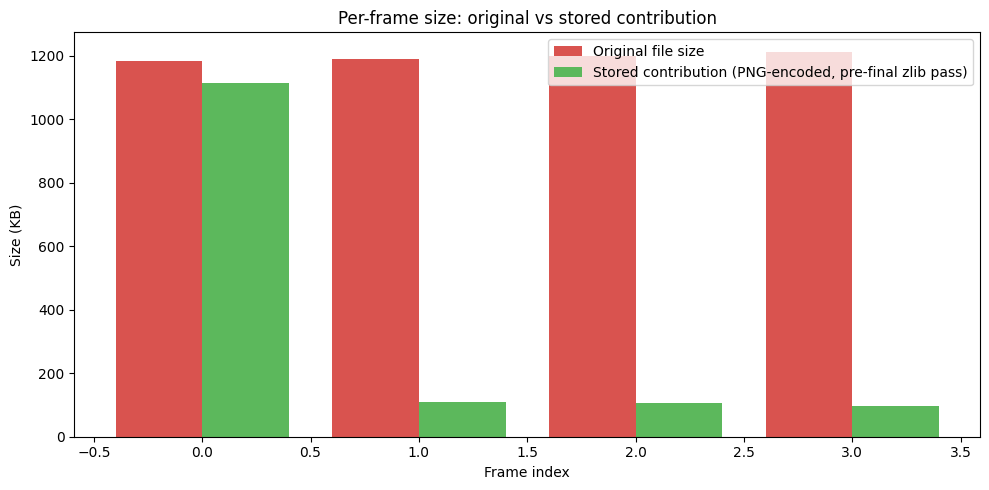

Frame   0 (face1.png): reference      -> 1114.93 KB (PNG)
Frame   1 (face2.png): patch          -> 108.91 KB (PNG)
Frame   2 (face3.png): patch          -> 106.54 KB (PNG)
Frame   3 (face4.png): patch          -> 98.23 KB (PNG)


In [26]:
frame_indices = list(range(len(images)))
stored_bytes = [s["stored_bytes"] for s in per_frame_stats]

plt.figure(figsize=(10, 5))
width = 0.4
plt.bar([i - width / 2 for i in frame_indices], [s / 1024 for s in original_sizes],
        width=width, label="Original file size", color="#d9534f")
plt.bar([i + width / 2 for i in frame_indices], [s / 1024 for s in stored_bytes],
        width=width, label="Stored contribution (PNG-encoded, pre-final zlib pass)", color="#5cb85c")
plt.xlabel("Frame index")
plt.ylabel("Size (KB)")
plt.title("Per-frame size: original vs stored contribution")
plt.legend()
plt.tight_layout()
plt.show()

for i, s in enumerate(per_frame_stats):
    print(f"Frame {i:>3} ({paths[i].name}): {s['kind']:<14} -> {s['stored_bytes'] / 1024:.2f} KB (PNG)")

### 6.3 Processing time

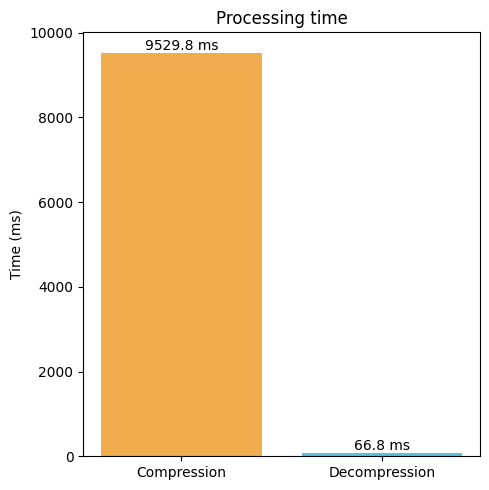

In [27]:
plt.figure(figsize=(5, 5))
bars = plt.bar(["Compression", "Decompression"], [compress_time * 1000, decompress_time * 1000],
               color=["#f0ad4e", "#5bc0de"])
plt.ylabel("Time (ms)")
plt.title("Processing time")
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f"{height:.1f} ms", ha="center", va="bottom")
plt.tight_layout()
plt.show()

### 6.4 Visual check: original vs reconstructed sample frames

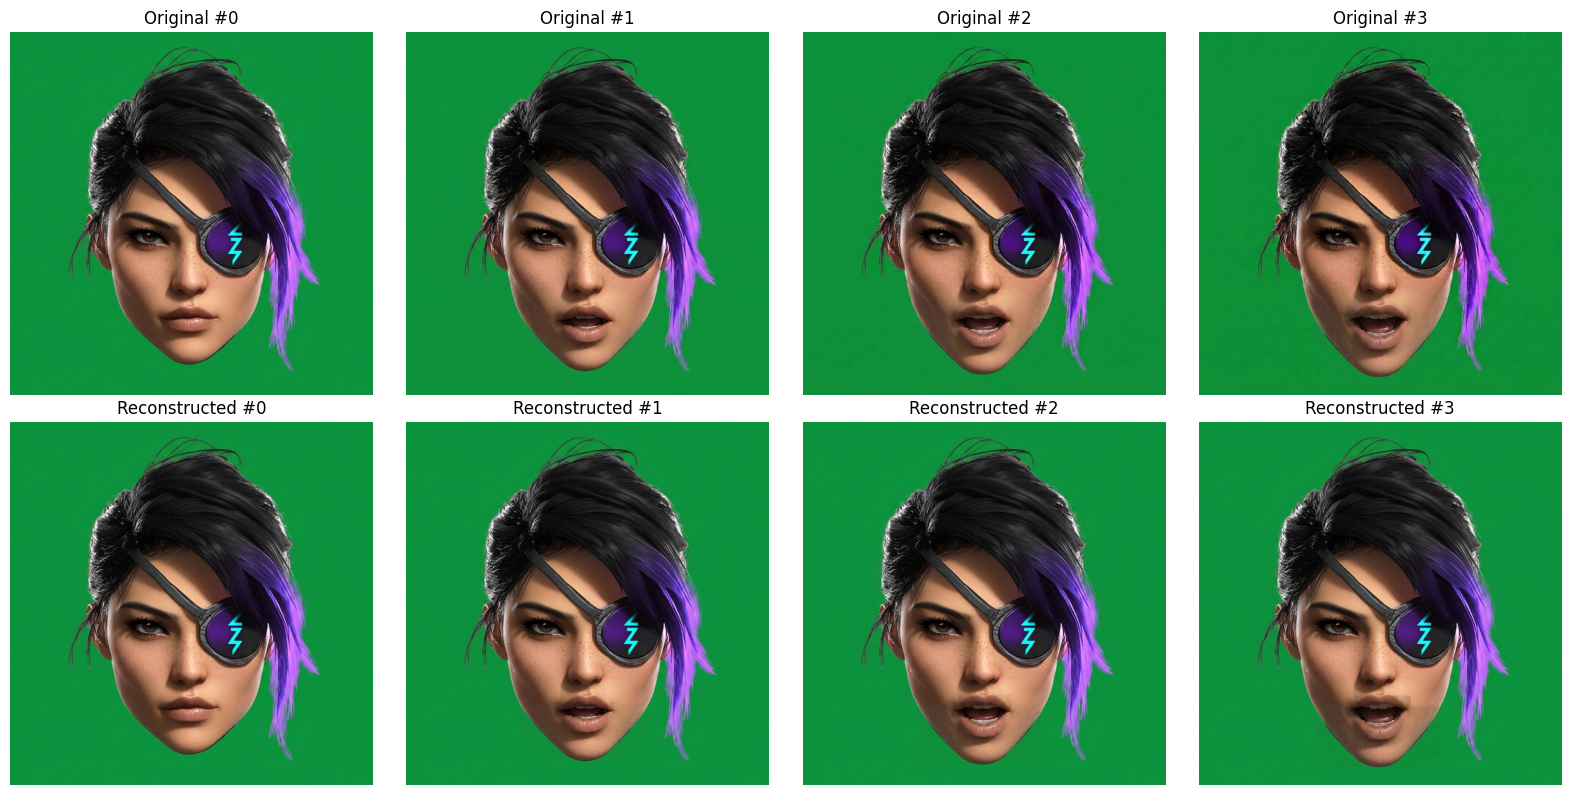

In [28]:
num_samples = min(4, len(images))
sample_indices = np.linspace(0, len(images) - 1, num_samples, dtype=int)

fig, axes = plt.subplots(2, num_samples, figsize=(4 * num_samples, 8))
if num_samples == 1:
    axes = axes.reshape(2, 1)

for col, idx in enumerate(sample_indices):
    axes[0, col].imshow(images[idx])
    axes[0, col].set_title(f"Original #{idx}")
    axes[0, col].axis("off")

    axes[1, col].imshow(reconstructed_images[idx])
    axes[1, col].set_title(f"Reconstructed #{idx}")
    axes[1, col].axis("off")

plt.tight_layout()
plt.show()

### 6.5 Where is the difference located? Change mask + patch regions per frame

This is the direct answer to "what is actually being compressed / reused":
- **`changed px %`**: the fraction of pixels that are *really* different from the previous frame
  (per `DIFF_THRESHOLD`), after removing blobs smaller than `MIN_BLOB_SIZE`.
- **`patch area %`**: the fraction of the frame covered by the stored patch region(s) - everything
  outside them is reused/compressed away for free.
- **`# patches`**: how many separate regions were found for that frame.

If `changed px %` is small but `patch area %` is still huge, either scattered noise below
`MIN_BLOB_SIZE` is still surviving (raise `MIN_BLOB_SIZE`), or a small number of real changes are
just spread far apart across the frame (raising `MIN_BLOB_SIZE`/`DIFF_THRESHOLD` won't help there -
that's a genuinely global change). The change-mask images below make this visible directly: a
background that looks identical to your eyes but is sprinkled with white dots is exactly the noise
problem. If you see that, tune `DIFF_THRESHOLD` / `MIN_BLOB_SIZE` in section 1 and re-run from there.

**If total space saved does not change no matter what you tune**: check `# patches` here. Lowering
`DIFF_THRESHOLD`/raising `MIN_BLOB_SIZE` shrinks the change mask, but if the surviving regions are
still scattered into more pieces than `MAX_PATCHES_PER_FRAME` (default 8), every frame keeps falling
back to `full` regardless - the mask changed but the final decision didn't. Raise
`MAX_PATCHES_PER_FRAME` in section 1 too in that case.

In [29]:
print(f"{'Frame':>5}  {'kind':<14}  {'changed px %':>13}  {'patch area %':>13}  {'# patches':>9}")
for i, s in enumerate(per_frame_stats):
    changed = f"{s['changed_pixel_ratio'] * 100:.2f}" if s["changed_pixel_ratio"] is not None else "-"
    area = f"{s['area_ratio'] * 100:.2f}" if s["area_ratio"] is not None else "-"
    num_patches = s["num_patches"] if s["num_patches"] is not None else "-"
    print(f"{i:>5}  {s['kind']:<14}  {changed:>13}  {area:>13}  {num_patches:>9}")

Frame  kind             changed px %   patch area %  # patches
    0  reference                   -              -          -
    1  patch                    2.30           7.94         12
    2  patch                    1.65           7.47         22
    3  patch                    1.28           7.07         14


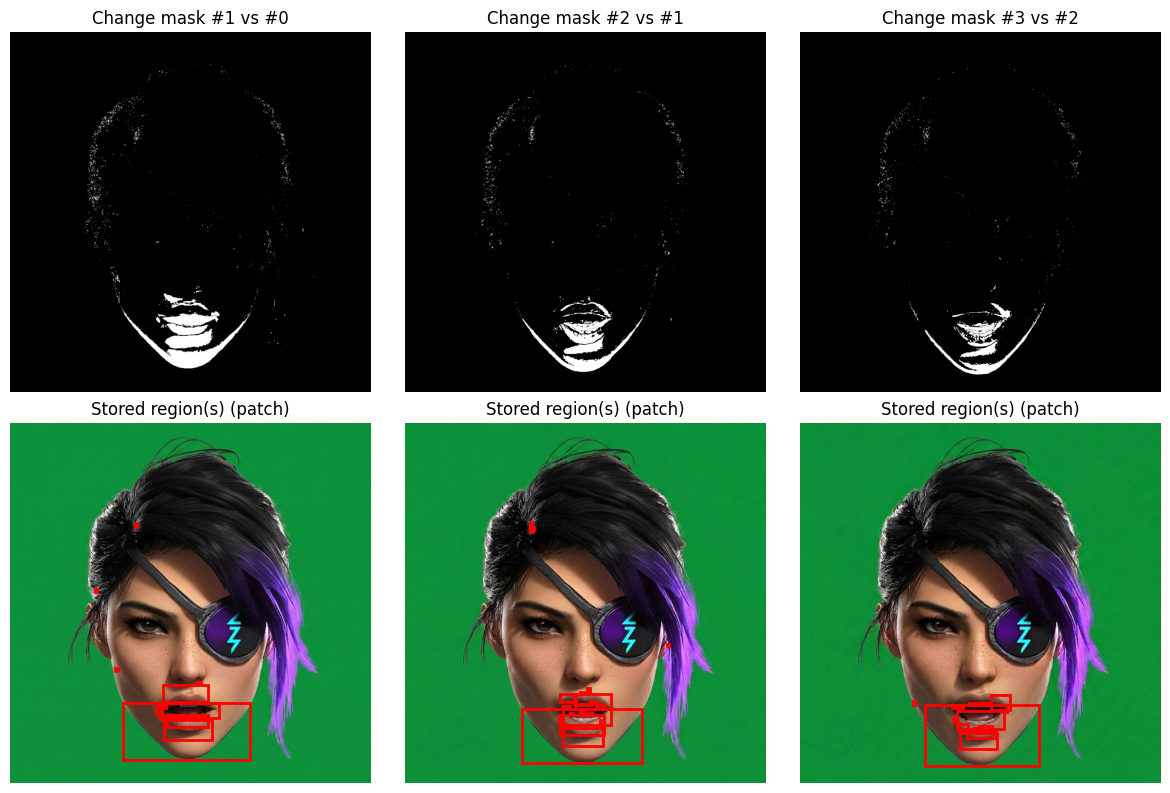

In [30]:
import matplotlib.patches as mpatches

non_reference = list(range(1, len(images)))

if non_reference:
    fig, axes = plt.subplots(2, len(non_reference), figsize=(4 * len(non_reference), 8))
    if len(non_reference) == 1:
        axes = axes.reshape(2, 1)

    for col, idx in enumerate(non_reference):
        diff = np.abs(images[idx].astype(np.int16) - images[idx - 1].astype(np.int16)).sum(axis=-1)
        mask = diff > DIFF_THRESHOLD

        axes[0, col].imshow(mask, cmap="gray")
        axes[0, col].set_title(f"Change mask #{idx} vs #{idx - 1}")
        axes[0, col].axis("off")

        axes[1, col].imshow(images[idx])
        for (y0, y1, x0, x1) in per_frame_stats[idx]["bboxes"] or []:
            rect = mpatches.Rectangle((x0, y0), x1 - x0, y1 - y0, linewidth=2, edgecolor="red", facecolor="none")
            axes[1, col].add_patch(rect)
        axes[1, col].set_title(f"Stored region(s) ({per_frame_stats[idx]['kind']})")
        axes[1, col].axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("Only one frame in the sequence, nothing to compare.")

### 6.6 Accumulated change across the whole sequence

Sums the change mask over every consecutive pair. Pixels that stay dark never change (pure
background, fully reused/compressed away across the sequence); pixels that light up are where
the sequence actually varies frame to frame.

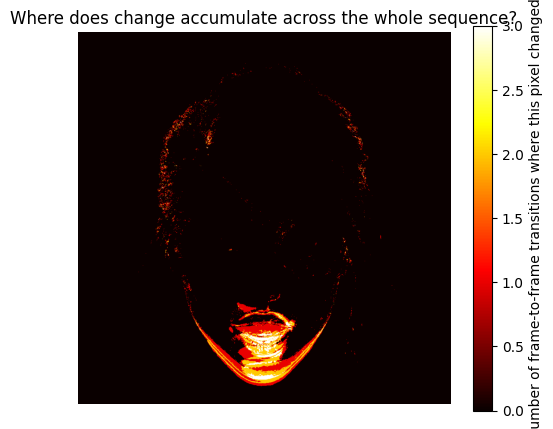

In [31]:
if len(images) > 1:
    union_mask = np.zeros(images[0].shape[:2], dtype=np.int32)
    for idx in range(1, len(images)):
        diff = np.abs(images[idx].astype(np.int16) - images[idx - 1].astype(np.int16)).sum(axis=-1)
        union_mask += (diff > DIFF_THRESHOLD).astype(np.int32)

    plt.figure(figsize=(6, 5))
    plt.imshow(union_mask, cmap="hot")
    plt.colorbar(label="Number of frame-to-frame transitions where this pixel changed")
    plt.title("Where does change accumulate across the whole sequence?")
    plt.axis("off")
    plt.show()
else:
    print("Need at least 2 frames to show accumulated change.")

## 7. Summary

- `identical` frames cost 0 bytes.
- `patch` frames only cost small PNGs of the regions that actually changed - possibly several per frame.
- `full_fallback` frames cost roughly the same as a normal PNG of that image (used when patching would not help).
- The final `zlib` pass mostly squeezes the metadata (bounding boxes, frame types), not the pixels themselves.

### Tuning knobs (section 1) to get more compression
- **`DIFF_THRESHOLD`** (color similarity): raise it to treat close colors as identical. Good for
  sequences with mild recompression noise or color banding, bad if it starts eating real low-contrast edits.
- **`MIN_BLOB_SIZE`** (noise filtering): raise it to ignore small isolated groups of changed pixels
  (dithering, per-pixel regeneration noise) without touching `DIFF_THRESHOLD`. This is usually the
  right first knob to try when `changed px %` is small but `patch area %` is large in section 6.5.
- **`MAX_PATCHES_PER_FRAME`** / **`MAX_PATCH_AREA_RATIO`**: control when the algorithm gives up on
  patching and just stores the full frame. Raise `MAX_PATCHES_PER_FRAME` if your edits legitimately
  happen in several separate spots per frame.

This approach only pays off when consecutive images share large unchanged regions (e.g. the same base
image with a small edited area, or a mostly-static background). If every frame in the sequence is an
independent full regeneration (e.g. different diffusion samples that differ across the whole image),
no amount of tuning will help - the diff is genuinely global, every frame falls back to `full`, and the
best you can expect is roughly the same size as compressing each image as PNG individually. Section 6.5
tells you which regime your sequence is in.